# **1. Download Dataset**

In [ ]:
import os
import zipfile
import urllib.request

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
zip_path = 'ml-latest-small.zip'

if not os.path.exists('ml-latest-small'):
    print('Downloading dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print('Download and extraction complete.')
else:
    print('Dataset already exists, skipping download.')

Download and extraction complete.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

project_path = '/content/drive/MyDrive/Colab Notebooks/PDS'
os.makedirs(project_path, exist_ok=True)
os.chdir(project_path)
print('Working directory set to:', os.getcwd())

# Define source and destination paths for the dataset
source_data_path = '/content/ml-latest-small'
dest_data_path = os.path.join(project_path, 'ml-latest-small')

# Copy the dataset to the project path if it doesn't already exist there
if os.path.exists(source_data_path) and not os.path.exists(dest_data_path):
    print(f'Copying dataset from {source_data_path} to {dest_data_path}...')
    shutil.copytree(source_data_path, dest_data_path)
    print('Dataset copied.')
elif os.path.exists(dest_data_path):
    print('Dataset already exists in project path, skipping copy.')
else:
    print(f'Source dataset directory {source_data_path} not found. Please ensure it is extracted first.')

Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/Colab Notebooks/PDS
Dataset already exists in project path, skipping copy.


## 2. Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## 3. Data Cleaning & Inspection

In [ ]:
print('Missing values in movies:\n', movies.isnull().sum())
print('\nMissing values in ratings:\n', ratings.isnull().sum())
print('\nDuplicate rows in movies:', movies.duplicated().sum())
print('Duplicate rows in ratings:', ratings.duplicated().sum())

Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Duplicate rows in movies: 0
Duplicate rows in ratings: 0


In [ ]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('float')
movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0


## 4. Merge Ratings + Movies

In [ ]:
df = pd.merge(ratings, movies, on='movieId')
print(df.shape)
df.head()

(100836, 7)


,userId,movieId,rating,timestamp,title,genres,year
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,1995.0
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,1995.0
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1995.0
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1995.0


## 5. Exploratory Data Analysis

/tmp/ipykernel_897/1406927726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


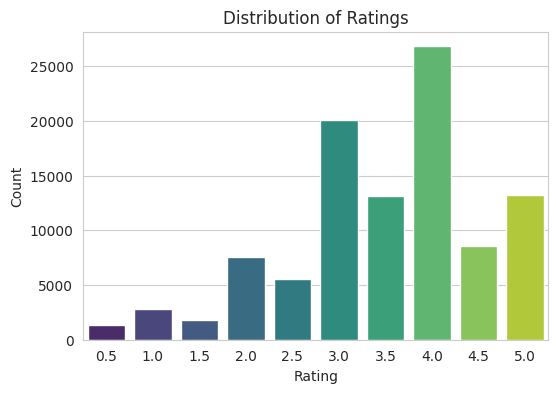

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### 5.2 Top 10 Highest Rated Movies (min. 50 ratings)

In [ ]:
movie_stats = df.groupby('title')['rating'].agg(['mean', 'count'])
movie_stats.columns = ['avg_rating', 'num_ratings']

top_movies = movie_stats[movie_stats['num_ratings'] >= 50].sort_values('avg_rating', ascending=False).head(10)
top_movies

,avg_rating,num_ratings
title,,
"Shawshank Redemption, The (1994)",4.429022,317
"Godfather, The (1972)",4.289062,192
Fight Club (1999),4.272936,218
Cool Hand Luke (1967),4.271930,57
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),4.268041,97
Rear Window (1954),4.261905,84
"Godfather: Part II, The (1974)",4.259690,129
"Departed, The (2006)",4.252336,107
Goodfellas (1990),4.250000,126


/tmp/ipykernel_897/810750830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies['avg_rating'], y=top_movies.index, palette='mako')


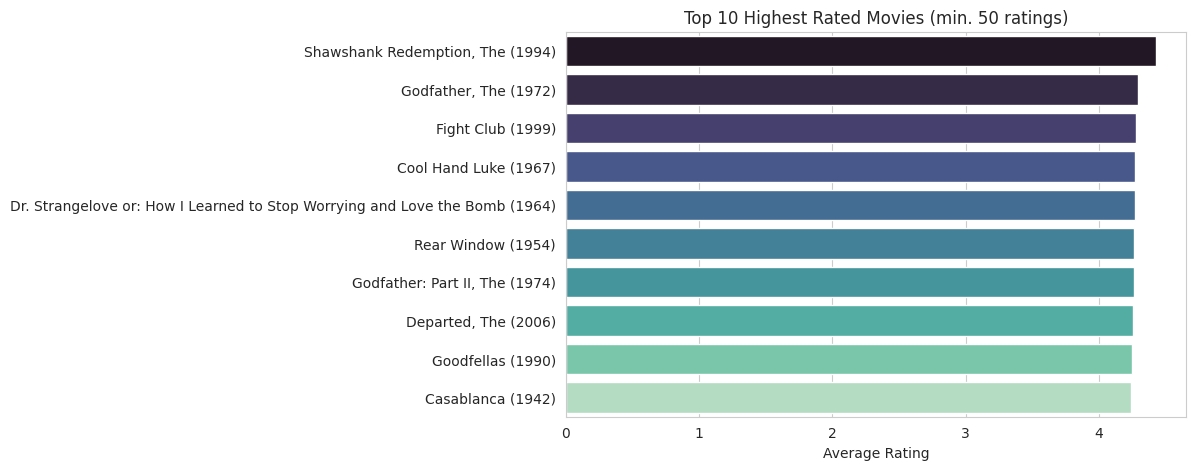

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_movies['avg_rating'], y=top_movies.index, palette='mako')
plt.title('Top 10 Highest Rated Movies (min. 50 ratings)')
plt.xlabel('Average Rating')
plt.ylabel('')
plt.show()

### 5.3 Most Popular Movies (by number of ratings)

In [ ]:
most_rated = movie_stats.sort_values('num_ratings', ascending=False).head(10)
most_rated

,avg_rating,num_ratings
title,,
Forrest Gump (1994),4.164134,329
"Shawshank Redemption, The (1994)",4.429022,317
Pulp Fiction (1994),4.197068,307
"Silence of the Lambs, The (1991)",4.161290,279
"Matrix, The (1999)",4.192446,278
Star Wars: Episode IV - A New Hope (1977),4.231076,251
Jurassic Park (1993),3.750000,238
Braveheart (1995),4.031646,237
Terminator 2: Judgment Day (1991),3.970982,224


/tmp/ipykernel_897/36532811.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_rated['num_ratings'], y=most_rated.index, palette='rocket')


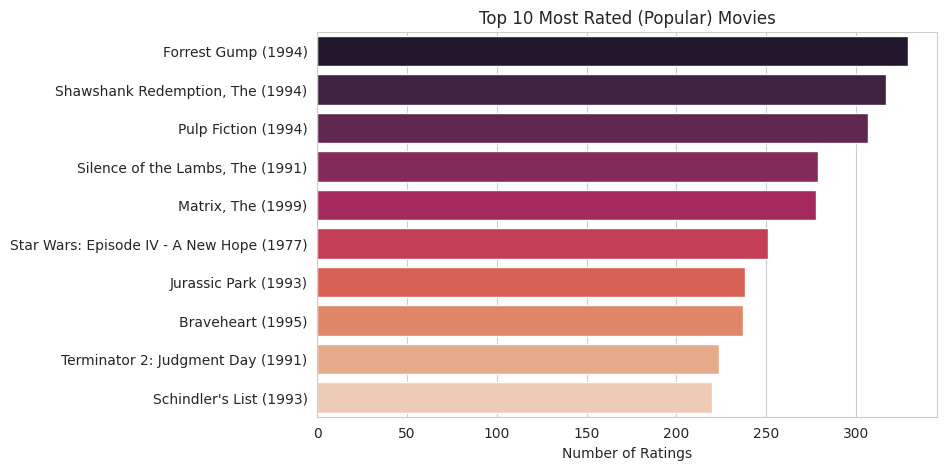

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=most_rated['num_ratings'], y=most_rated.index, palette='rocket')
plt.title('Top 10 Most Rated (Popular) Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('')
plt.show()

### 5.4 Number of Movies per Genre

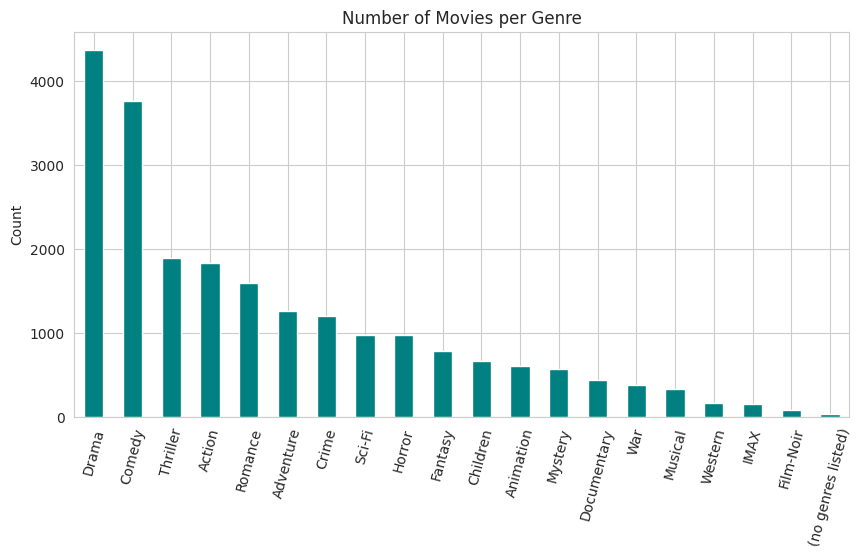

In [ ]:
genre_df = movies['genres'].str.get_dummies('|')
genre_counts = genre_df.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar', color='teal')
plt.title('Number of Movies per Genre')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.show()

### 5.5 Average Rating per Genre

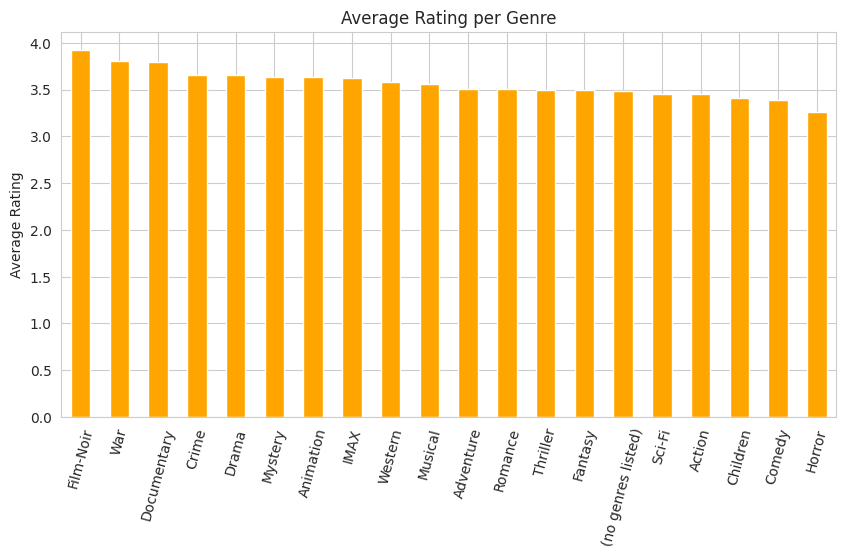

In [ ]:
genre_ratings = {}
for genre in genre_df.columns:
    genre_movie_ids = movies.loc[genre_df[genre] == 1, 'movieId']
    avg = df[df['movieId'].isin(genre_movie_ids)]['rating'].mean()
    genre_ratings[genre] = avg

genre_rating_series = pd.Series(genre_ratings).sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_rating_series.plot(kind='bar', color='orange')
plt.title('Average Rating per Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=75)
plt.show()

### 5.6 Ratings Trend Over the Years

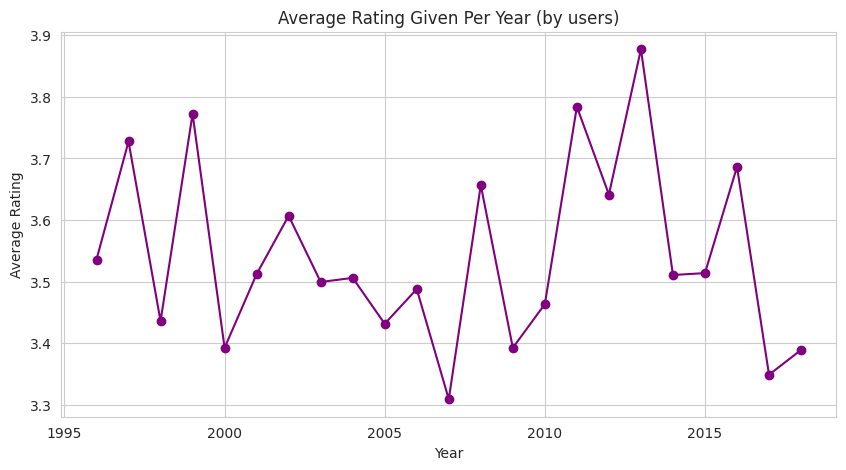

In [ ]:
df['rating_year'] = pd.to_datetime(df['timestamp'], unit='s').dt.year

yearly_avg = df.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(10,5))
yearly_avg.plot(marker='o', color='purple')
plt.title('Average Rating Given Per Year (by users)')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

### 5.7 Correlation: Number of Ratings vs Average Rating

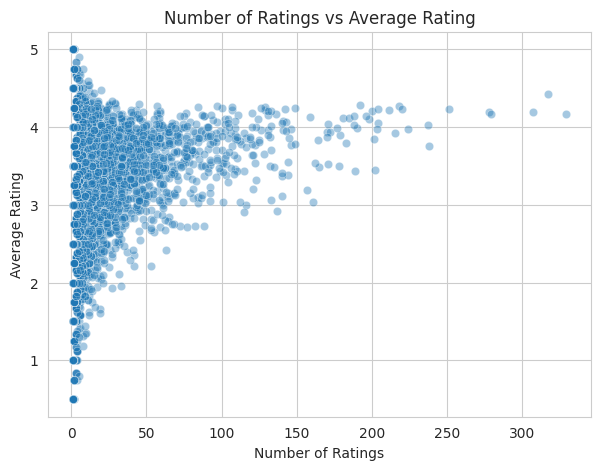

Correlation coefficient: 0.127


In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='num_ratings', y='avg_rating', data=movie_stats, alpha=0.4)
plt.title('Number of Ratings vs Average Rating')
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.show()

correlation = movie_stats['num_ratings'].corr(movie_stats['avg_rating'])
print('Correlation coefficient:', round(correlation, 3))

## 6. Summary of Finding
• Most ratings fall between 3.0 and 4.0, showing users tend to rate movies they liked.

• Highest-rated movies (with enough votes) are mostly older, well-known classics rather than
recent releases.

• Popularity (number of ratings) does not always match quality (average rating).

• Drama and Comedy are the most common genres, but niche genres often have slightly higher
average ratings.

• Average ratings given by users have stayed fairly stable across years.

• There is a weak positive correlation between number of ratings and average rating.


In [7]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the datasets using relative paths, as the working directory is set correctly
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

# Merge ratings and movies to create the df DataFrame
df = pd.merge(ratings, movies, on='movieId')

# Rebuild the same stats you already have
movie_stats = df.groupby('title')['rating'].agg(['mean', 'count'])
movie_stats.columns = ['avg_rating', 'num_ratings']

top_movies = movie_stats[movie_stats['num_ratings'] >= 50].sort_values('avg_rating', ascending=False).head(10)
most_rated = movie_stats.sort_values('num_ratings', ascending=False).head(10)

genre_df = movies['genres'].str.get_dummies('|')
genre_counts = genre_df.sum().sort_values(ascending=False)

genre_ratings = {}
for genre in genre_df.columns:
    ids = movies.loc[genre_df[genre] == 1, 'movieId']
    genre_ratings[genre] = df[df['movieId'].isin(ids)]['rating'].mean()
genre_rating_series = pd.Series(genre_ratings).sort_values(ascending=False)

df['rating_year'] = pd.to_datetime(df['timestamp'], unit='s').dt.year
yearly_avg = df.groupby('rating_year')['rating'].mean()

# Build dashboard: 6 charts in a grid
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Distribution of Ratings", "Top 10 Highest Rated Movies",
        "Top 10 Most Popular Movies", "Movies per Genre",
        "Average Rating per Genre", "Ratings Trend Over Years"
    ),
    vertical_spacing=0.12, horizontal_spacing=0.1
)

fig.add_trace(go.Histogram(x=df['rating'], marker_color='#5B8FF9', name='Ratings'), row=1, col=1)
fig.add_trace(go.Bar(x=top_movies['avg_rating'], y=top_movies.index, orientation='h', marker_color='#5AD8A6', name='Top Rated'), row=1, col=2)
fig.add_trace(go.Bar(x=most_rated['num_ratings'], y=most_rated.index, orientation='h', marker_color='#F6BD16', name='Most Popular'), row=2, col=1)
fig.add_trace(go.Bar(x=genre_counts.index, y=genre_counts.values, marker_color='#5D7092', name='Genre Count'), row=2, col=2)
fig.add_trace(go.Bar(x=genre_rating_series.index, y=genre_rating_series.values, marker_color='#E8684A', name='Genre Avg Rating'), row=3, col=1)
fig.add_trace(go.Scatter(x=yearly_avg.index, y=yearly_avg.values, mode='lines+markers', marker_color='#9270CA', name='Yearly Trend'), row=3, col=2)

fig.update_layout(
    height=1200, width=1300,
    title_text="🎬 Movie Rating Analysis Dashboard",
    title_font_size=24,
    showlegend=False,
    template='plotly_white'
)

fig.write_html('movie_dashboard.html')
fig.show()